In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import pickle

from sven.nn import SvenWrapper
from experiments.nn import MLP
from sven.opt import Sven

import sys
sys.path.append('../..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False,
    'mathtext.fontset': 'cm',
})

# Output directory for plots
PLOT_DIR = Path('plots/1d_regression/')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

Using device: mps
Plots will be saved to: /Users/sambt/iaifi/sv3/claude_experiments/batched_param_experiments/plots/1d_regression


In [2]:
LOADER_SEED = 292501
MODEL_SEED = 63644
DATA_SEED = 710931
batch_size = 32
param_fractions = [None, 0.9, 0.7, 0.5, 0.3, 0.1]
K = 16
lr_svd = 0.1
n_epoch = 20
lr_standard = 1e-3
rtol = 1e-3
mlp_kwargs = {
    "input_dim": 1,
    "hidden_dims": [16,16,16],
    "output_dim": 1
}
standard_optimizers = ['Adam','SGD','RMSprop']

In [3]:
from torchvision import datasets, transforms
from experiments.datasets import Toy1DRegressionDataset

toy_1d = Toy1DRegressionDataset(seed=DATA_SEED)
train_dataset = toy_1d.train_dataset
test_dataset = toy_1d.val_dataset

In [4]:
set_seed(MODEL_SEED)
mlp_base = MLP(**mlp_kwargs)
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

### Baseline trainings

In [5]:
device = 'cpu'
new_rows = []
for opt_name in standard_optimizers:
    for lr_standard in [0.1,0.01,0.001]:
        #if lr_standard in df_baseline[df_baseline['optimizer'] == opt_name].lr.values:
        #    continue
        print(f"Running standard training with optimizer: {opt_name}, lr: {lr_standard}")
        model_standard = MLP(**mlp_kwargs)
        model_standard.load_state_dict(init_state)
        model_standard = model_standard.to(device)

        opt = getattr(torch.optim, opt_name)
        optimizer = opt(model_standard.parameters(), lr=lr_standard if opt_name != 'SGD' else lr_svd)
        loss_fn = nn.MSELoss()

        train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
        test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

        model_standard, losses = train_loop_standard(model_standard, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

        new_row = {
            'optimizer': opt_name,
            'lr': lr_standard,
            'batch_size': batch_size,
            'losses': losses}
        new_rows.append(new_row)
#df_baseline = pd.concat([df_baseline, pd.DataFrame(new_rows)], ignore_index=True)
df_baseline = pd.DataFrame(new_rows)

Running standard training with optimizer: Adam, lr: 0.1
Using device cpu


100%|██████████| 20/20 [00:02<00:00,  8.69it/s]


Running standard training with optimizer: Adam, lr: 0.01
Using device cpu


100%|██████████| 20/20 [00:02<00:00,  9.21it/s]


Running standard training with optimizer: Adam, lr: 0.001
Using device cpu


...

100%|██████████| 20/20 [00:02<00:00,  9.80it/s]


Running standard training with optimizer: RMSprop, lr: 0.01
Using device cpu


100%|██████████| 20/20 [00:02<00:00,  9.68it/s]


Running standard training with optimizer: RMSprop, lr: 0.001
Using device cpu


100%|██████████| 20/20 [00:02<00:00,  9.57it/s]


### SVD training with varying microbatch

In [21]:
if device == torch.device('mps'):
    device = 'cpu'  # SVD optimizer not supported on MPS
svd_info = {}
losses_svd = {}
for param_fraction in param_fractions:
    print("Running for param fraction:", param_fraction)
    model_svd = MLP(**mlp_kwargs)
    model_svd.load_state_dict(init_state)
    model_svd = model_svd.to(device)

    def loss_fn(pred,y):
        loss = (pred - y)**2
        loss = loss.sum(dim=-1)
        return loss

    #lr_eff = lr_svd / (param_fraction if param_fraction is not None else 1.0)
    model_svd = SvenWrapper(model_svd, loss_fn, param_fraction=param_fraction, device=device)
    optimizer = Sven(model_svd,lr=lr_svd,k=K,rtol=rtol,track_svd_info=True,svd_mode='randomized')


    train_loader = DataLoader(toy_1d.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED),drop_last=True)
    test_loader = DataLoader(toy_1d.val_dataset, batch_size=256, shuffle=False)

    model_svd, losses_run, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
    svd_info[param_fraction] = optimizer.svd_info
    losses_svd[param_fraction] = losses_run

    torch.compiler.reset()

Running for param fraction: None


100%|██████████| 20/20 [00:09<00:00,  2.15it/s]


Running for param fraction: 0.9


100%|██████████| 20/20 [00:15<00:00,  1.33it/s]


Running for param fraction: 0.7


...

100%|██████████| 20/20 [00:12<00:00,  1.63it/s]


Running for param fraction: 0.3


100%|██████████| 20/20 [00:12<00:00,  1.57it/s]


Running for param fraction: 0.1


100%|██████████| 20/20 [00:11<00:00,  1.77it/s]


### Make plots

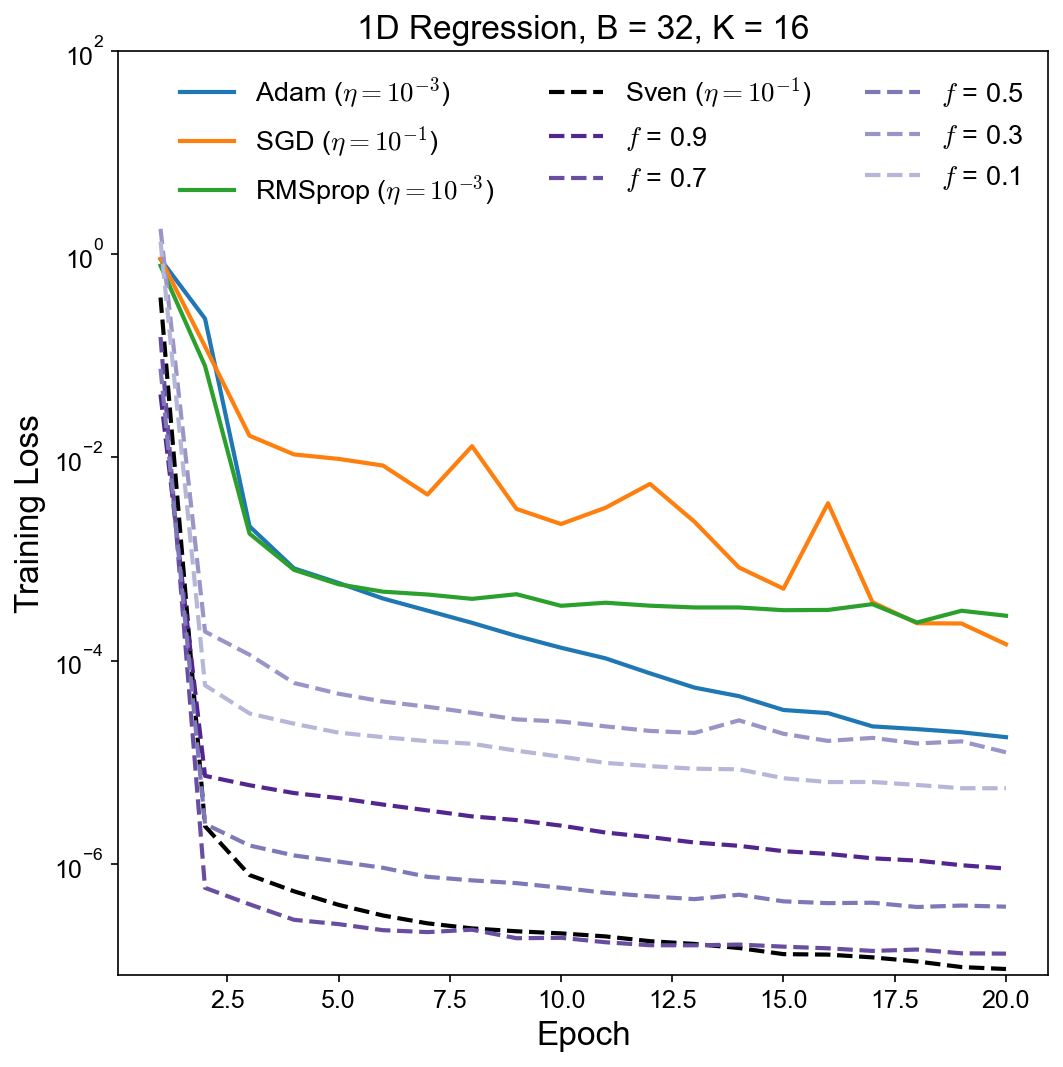

In [24]:
fig, ax = plt.subplots(figsize=(8,8))

LR_BASELINE = 1e-3
for i,opt in enumerate(standard_optimizers):
    LR_BASELINE = {'Adam':1e-3, 'RMSprop':1e-3, 'SGD':0.1}
    df_sel = df_baseline[(df_baseline['optimizer'] == opt) & (df_baseline['lr'] == LR_BASELINE[opt])].iloc[0]
    x = np.arange(1,21)
    y = df_sel['losses']['train']
    ax.plot(x,y,f'C{i}-', label=f'{opt} ($\\eta=10^{{{int(np.log10(LR_BASELINE[opt]))}}}$)')

cmap = plt.get_cmap('Purples')
for i, mb in enumerate(param_fractions):
    col_frac = 0.4 + 0.6*((len(param_fractions)-1-i)/ (len(param_fractions)-1))
    col = cmap(col_frac)
    if mb == None:
        col = 'k'
    label = rf'$f$ = {mb}' if mb is not None else f'Sven ($\\eta=10^{{{int(np.log10(lr_svd))}}}$)'
    x = np.arange(1,21)
    ax.plot(x, losses_svd[mb]['train'], 
            color=col, label=label, linestyle='--')
    
ax.set_title(f"1D Regression, B = {batch_size}, K = {K}")
ax.set_ylabel("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(8e-8, 1e2)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3,fontsize=13)
plt.savefig(PLOT_DIR / f"train_loss_1d_regression_param_frac_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")

NameError: name 'losses_standard' is not defined

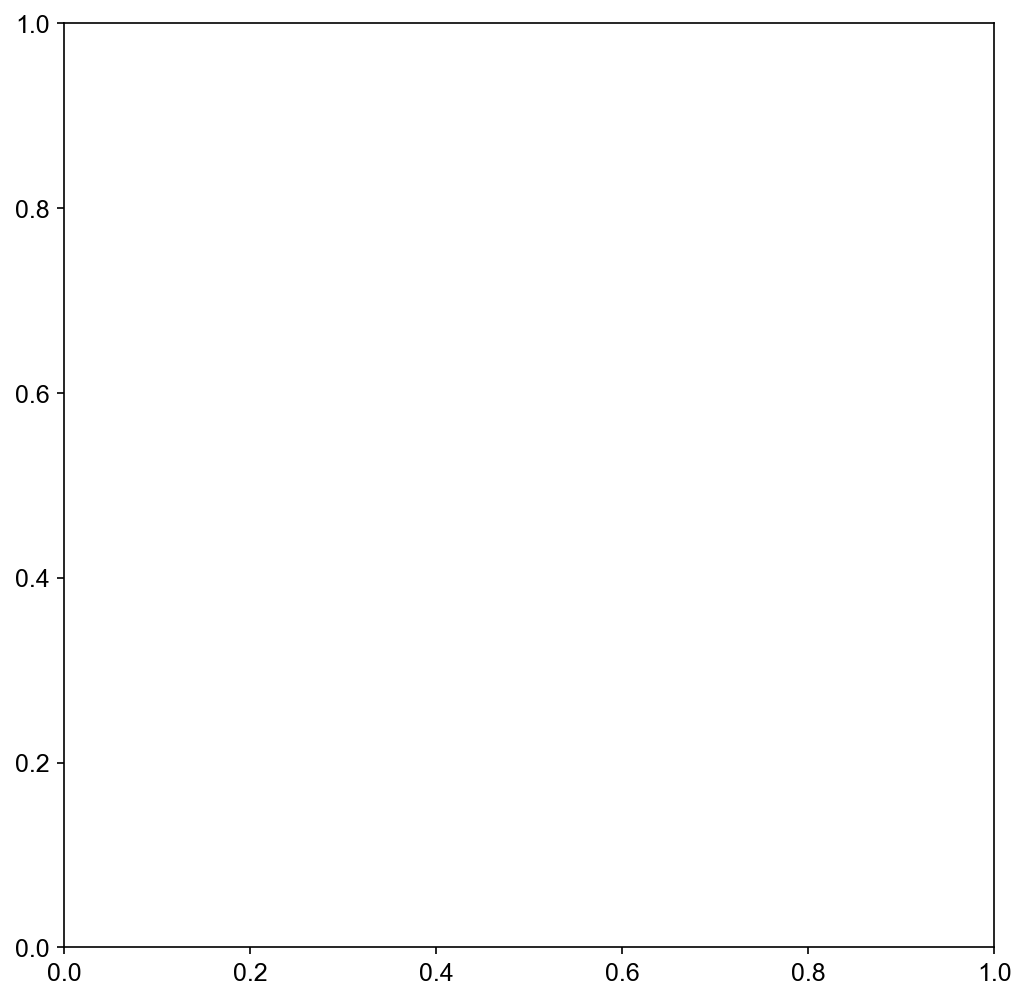

In [89]:
fig, ax = plt.subplots(figsize=(8,8))
for i,opt in enumerate(standard_optimizers):
    ax.plot(np.arange(len(losses_standard[opt]['val'])), losses_standard[opt]['val'], f'C{i}-', label=f'{opt}')
for i, mb in enumerate(microbatch_sizes):
    gray_intensity = 0.2 + (i / (len(microbatch_sizes) - 1)) * 0.5
    label = rf'SVD, $\mu$B = {mb}' if mb > 1 else 'SVD'
    ax.plot(np.arange(len(losses_svd[mb]['val'])), losses_svd[mb]['val'], 
            color=str(gray_intensity), label=label, linestyle='--')
    
ax.set_title(f"bs = {batch_size}")
ax.set_ylabel("Validation Loss")
ax.set_xlabel("Epoch")
ax.set_ylim(1e-8, 1e2)
plt.yscale('log')
plt.legend(loc='upper right',ncol=3)
plt.savefig(PLOT_DIR / f"val_loss_1d_regression_microbatch_comparison_bs{batch_size}_K{K}_lr{lr_svd}_rtol{rtol}.png")